In [1]:
# SimPEG functionality
from simpeg import maps, utils, data, optimization, maps, regularization, directives
from simpeg.electromagnetics import natural_source as nsem
from simpeg.utils import model_builder

# discretize functionality
from discretize import TreeMesh
from discretize.utils import mkvc, active_from_xyz

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Define the topography

In [2]:
x_topo, y_topo = np.meshgrid(
    np.linspace(-14000, 14000, 200), np.linspace(-14000, 14000, 200)
)
z_topo = np.zeros((len(x_topo), len(y_topo)))

x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)]

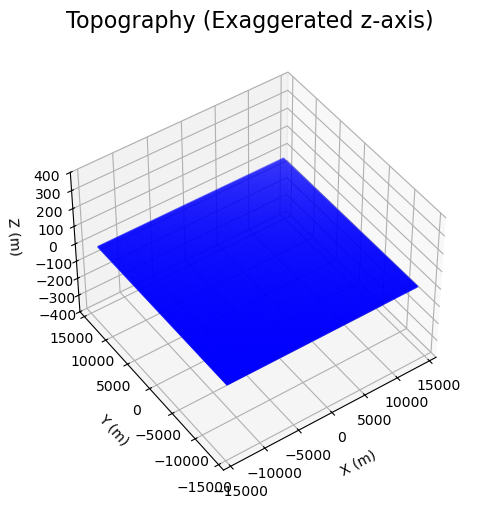

In [3]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([-400, 400])
ax.scatter3D(topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2], s=0.25, c="b")
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=45.0, azim=-125)

# Setup Reciever Locations

In [4]:
x_positions = [
    -5000, -2000, -1500, -1000, -750, -500, -400, -300, -250, -200,
    -150, -125, -100, -90, -80, -70, -60, -50, -40, -30,
    -20, -10, 0, 10, 20, 30, 40, 50, 60, 70,
    80, 90, 100, 125, 150, 200, 250, 300, 400, 500,
    750, 1000, 1500, 2000, 5000
]

y_positions = [
    -5000, -2000, -1500, -1000, -750, -500, -400, -300, -250, -200,
    -150, -125, -100, -90, -80, -70, -60, -50, -40, -30,
    -20, -10, 0, 10, 20, 30, 40, 50, 60, 70,
    80, 90, 100, 125, 150, 200, 250, 300, 400, 500,
    750, 1000, 1500, 2000, 5000
]

rx_locs = []

for x in x_positions:
    for y in y_positions:
        loc = [x,y,0]
        rx_locs += loc

rx_locs = np.array(rx_locs)
rx_locs = rx_locs.reshape(2025,3)

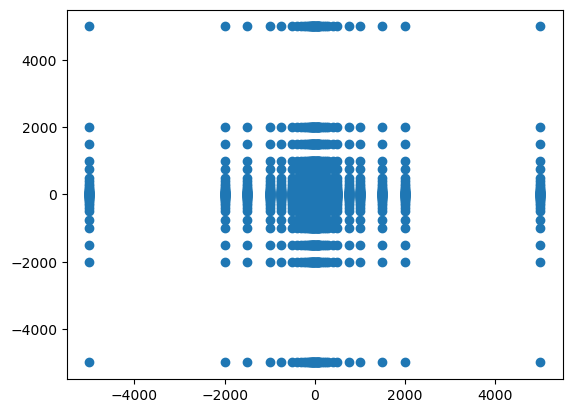

In [5]:
plt.scatter(rx_locs[:,0], rx_locs[:,1])

# Define Mesh

In [6]:
# Defining domain size and minimum cell size
dh = 50  # base cell width
dom_width_x = 16000.0  # domain width x
dom_width_y = 16000.0  # domain width y
dom_width_z = 4000.0  # domain width z

# Number of base mesh cells in each direction. Must be a power of 2
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcy = 2 ** int(np.round(np.log(dom_width_y / dh) / np.log(2.0)))  # num. base cells y
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh
hx = [(dh, nbcx)]
hy = [(dh, nbcy)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hy, hz], x0="CCN", diagonal_balance=True)

# Mesh refinement near electrodes.
refine_pts = np.zeros((len(rx_locs) + 1, 3))
for i, pt in enumerate(rx_locs): refine_pts[i] = [pt[0], pt[1], 0]
refine_pts[-1] = [0, 0, -1000]
mesh.refine_points(refine_pts, padding_cells_by_level=[2, 1], finalize=False)

# Finalize the mesh
mesh.finalize()
print(f"Mesh cells: {mesh.nC:,}")
print(f"Estimated RAM needed: ~{mesh.nC * 0.0002:.1f} GB")

Mesh cells: 17,320
Estimated RAM needed: ~3.5 GB


# Setup Model

In [7]:
active_cells = active_from_xyz(mesh, topo_xyz)
n_active = np.sum(active_cells)

background_conductivity = 0.001
sphere_conductivity = 10

conductivity_model = background_conductivity * np.ones(n_active)

sphere_indices = model_builder.get_indices_sphere(center=[0,0,-1000], radius=500, cell_centers=mesh.cell_centers[active_cells, :])
conductivity_model[sphere_indices] = sphere_conductivity


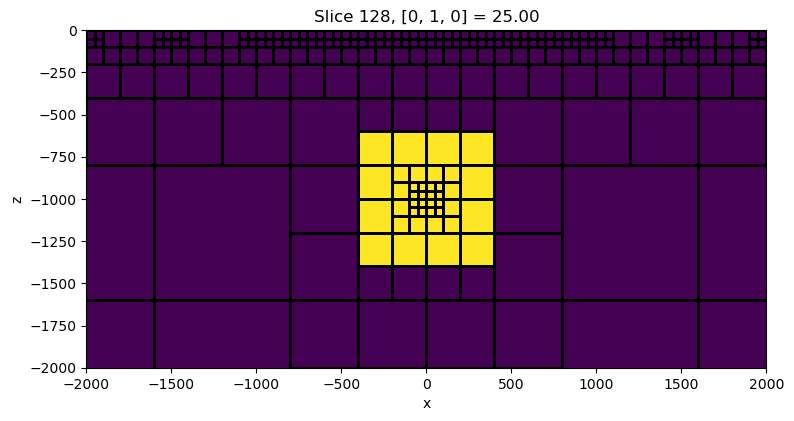

In [8]:
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

fig = plt.figure(figsize=(10, 4.5))

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    plotting_map * conductivity_model,
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2),
    grid=True,
)

ax1.set_xlim([-2000, 2000])
ax1.set_ylim([-2000, 0])
plt.show()

# Setup frequencies and survey

In [27]:
low_freq = 0.001
high_freq = 10000
samples_per_dec = 10

freqs = np.logspace(-3, 4, 10*7+1)

source_list = []

for f in freqs:
    rx_list = [
        nsem.receivers.Impedance(rx_locs, orientation='xy', component='real'),
        nsem.receivers.Impedance(rx_locs, orientation='xy', component='imag'),
        nsem.receivers.Impedance(rx_locs, orientation='yx', component='real'),
        nsem.receivers.Impedance(rx_locs, orientation='yx', component='imag'),
    ]
    
    source_list.append(nsem.sources.PlanewaveXYPrimary(rx_list, frequency=f, sigma_primary=conductivity_model))

survey = nsem.survey.Survey(source_list)

# Setup and Run Sim

In [28]:
sim = nsem.Simulation3DPrimarySecondary(
    mesh,
    survey=survey,
    sigmaMap=maps.IdentityMap(mesh)
)

dpred = sim.dpred(conductivity_model)
print("Expected data shape:", len(freqs) * len(rx_locs) * 4)
print("Survey data shape:", dpred.shape)

c:\Users\ryds1\miniconda3\envs\simpeg-mt-env\lib\site-packages\simpeg\base\pde_simulation.py:490: DefaultSolverWarning: Using the default solver: Pardiso. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)


Expected data shape: 575100
Survey data shape: (575100,)


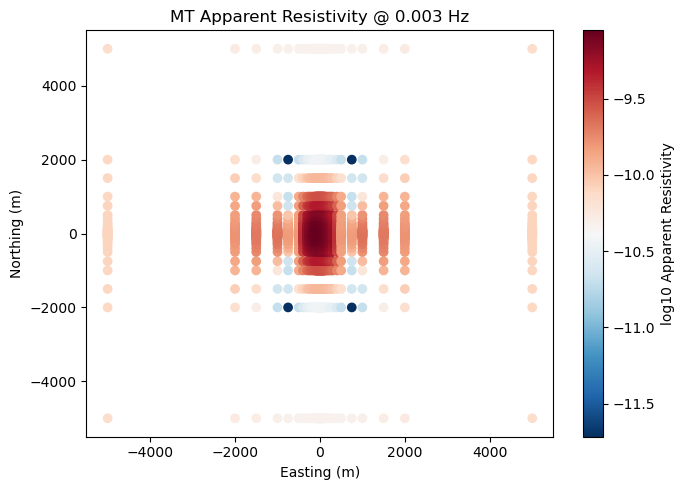

In [29]:
import matplotlib.pyplot as plt

# Reshape apparent resistivity for a single frequency
freq_idx = 5  # pick a frequency index
n_rx = len(rx_locs)

rho_xy = np.abs(dpred.reshape(len(freqs), -1)[freq_idx, :n_rx])

plt.figure(figsize=(7, 5))
plt.scatter(rx_locs[:, 0], rx_locs[:, 1], c=np.log10(rho_xy), cmap='RdBu_r')
plt.colorbar(label='log10 Apparent Resistivity')
plt.title(f'MT Apparent Resistivity @ {freqs[freq_idx]:.3f} Hz')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.tight_layout()
plt.show()